# Australian Rental Market Analysis

**GAO Innovation Lab Interview Submission**  
**Analyst:** Justin Hoffman  
**Date:** March 5, 2026

## Project Overview

This analysis uses the Australian Rental Market Data 2026 dataset to identify the main drivers of weekly rent and test whether certain amenities are associated with higher rents after accounting for property fundamentals and geography.

## The Analytical Approach

### Supervised learning

I chose supervised learning because I wanted to explain variation in rent and identify which factors were driving it. Since rent is directly observed in the dataset, a supervised regression approach is the most direct way to answer that question. Unsupervised methods such as clustering could have grouped listings into market segments, but they would not have directly answered which variables are associated with higher or lower rent.

The modeling approach used in this project also gave me an opportunity to build on recent coursework from **CS 441: Applied Machine Learning** at UIUC, which I am currently taking. For context, I included links to related completed coursework below.

Related coursework: 
- [UIUC Regression notebook](https://github.com/jhffmn82/gao-rental-project-support/blob/418ae201859874504b7bbb4f1be8a9a77353e811/Regression.ipynb)
- [UIUC GLMnet notebook](https://github.com/jhffmn82/gao-rental-project-support/blob/418ae201859874504b7bbb4f1be8a9a77353e811/GLMnet.ipynb)

## Modeling Choices

I used regularized linear regression, specifically Ridge and Lasso, implemented in Python with scikit-learn.

These models were appropriate for three main reasons:

- **Interpretability**  
  Linear models provide coefficients that estimate how each feature is associated with rent. This makes the results easier to explain to non-technical stakeholders.

- **Large number of predictors**  
  After converting categorical variables such as postcode into indicator variables, the model includes a large number of predictors. With about 6,800 listings and more than 1,000 postcode categories, ordinary least squares can become unstable. Regularization helps control this by shrinking coefficients.

- **Feature selection**  
  Lasso can shrink weak predictors all the way to zero, which helps identify which amenities appear to carry real signal and which do not add much explanatory value.

Ridge (L2) shrinks coefficients toward zero but retains all predictors in the model. This works well when many variables each contribute a small amount of signal, such as geographic effects where many postcode indicators each capture part of the pricing pattern.

Lasso (L1) applies a penalty that can shrink some coefficients to exactly zero, effectively removing weaker predictors. This is particularly useful when modeling amenities, where many features appear together and only a subset carries meaningful signal. In later stages of the analysis, Lasso also helps distinguish between the value of specific amenities and the broader premium associated with feature-rich listings.

The regularization parameter (`alpha`) was tuned using 5-fold cross-validation on the training data, selecting the value that minimized mean absolute error on log-transformed rent. Final performance was evaluated on a held-out test set (25% of the data, stratified by state to ensure similar state representation in the training and test sets) using both log-scale metrics (**MAE_log**, **R2_log**) and original-rent metrics (**MAE_rent**, **R2_rent**). On the log scale, model errors correspond approximately to percentage differences in rent, which provides a useful way to compare predictive accuracy.

## Why Log-Transform Rent?

`price_display` is right-skewed, so a small number of very expensive listings would otherwise have disproportionate influence on the model. Applying `log(1 + rent)` compresses the upper tail, stabilizes variance, and makes errors more comparable across lower- and higher-rent listings. This is equivalent to a Box-Cox transformation with lambda approaching zero.

## Tools

| Tool | Purpose |
|---|---|
| pandas / numpy | Data loading, cleaning, feature engineering |
| scikit-learn | Ridge, Lasso, cross-validation |
| matplotlib | All visualizations |
| scipy.stats | Additional statistical testing used in H5 |
| Kaggle | Dataset source and notebook environment |

## Execution

The analysis builds the predictive model incrementally across five hypotheses, with each stage motivated by the previous one:

### 1. Data Quality Check

Before modeling, the dataset was reviewed for missing values, duplicate listings, unusual outliers, and very high-cardinality fields. This step helped determine what cleaning was required and which variables could be used safely in the model.

### 2. Exploratory Data Analysis

Initial visualizations were used to understand the structure of the data. These included the distribution of rent, which motivated the log transformation, rent by property size, rent by state, simple comparisons of rent across amenities, and the distribution of amenity richness.

### 3. Iterative Model Development

I iteratively built predictive models using Ridge and Lasso regression, progressively adding feature groups. Each stage increases explanatory power while also clarifying how different types of information contribute to rental prices.

### H1: Fundamentals

The first model uses only basic property characteristics: bedrooms, bathrooms, parking spaces, and property type. This establishes a baseline showing how much rent can be explained by the physical features of a property alone.

### H2: Location Effect

Next, geographic information is added by including state and postcode. This tests how much additional explanatory power comes from knowing where a property is located.

### H3: Amenities

Amenity information is then incorporated. Amenities are originally stored as text, so they are tokenized and converted into indicator variables before being included in the model. I then test whether these features improve predictive performance beyond fundamentals and location.

### H4: Amenity Effects

Lasso regression is used to examine which amenities retain meaningful coefficients after controlling for property fundamentals and geography. Because Lasso can shrink weaker predictors to zero, it helps identify which amenities appear to be associated with higher or lower rent.

### H5: Amenity Richness Adjustment

Finally, I introduce an `amenity_count` variable representing the total number of listed amenities for each property and refit the model. This allows me to distinguish between the general premium associated with feature-rich listings and the distinct associations of specific amenities. The final model from this step is then used to interpret the value added by individual amenities after adjusting for overall amenity richness.

In [59]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

## 1. Data Loading

Begin by locating and loading the dataset from the Kaggle input directory.
A quick shape and column check confirms the data loaded correctly before 
any analysis begins.

In [60]:
DATA_PATH = csv_paths[0]
df = pd.read_csv(DATA_PATH)

rows, cols = df.shape
print(f"Loaded {rows} rows and {cols} columns")
print("\nColumns:")
print(df.columns.tolist())

Loaded 6767 rows and 16 columns

Columns:
['title', 'price_display', 'description', 'propertyType', 'locality', 'latitude', 'longitude', 'postcode', 'state', 'street_address', 'suburb', 'bathrooms', 'bedrooms', 'parking_spaces', 'agency_name', 'amenities']


## 2. Data Quality Assessment

Before building any models, I reviewed the dataset to identify potential data quality issues that could affect the analysis. This included checking for missing values, duplicate listings, unusual outliers, and variables with very large numbers of categories.

Key questions at this stage were:

- Are any important fields missing values?
- Are there duplicate listings to remove?
- Is the target variable skewed?
- Are there high-cardinality fields?

In [61]:
# List missing values
missing_info = []

for col in df.columns:
    missing_count = df[col].isna().sum()
    missing_pct = round((missing_count / len(df)) * 100, 2)

    missing_info.append({"column": col, "missing_count": missing_count, "missing_pct": missing_pct })

missing_summary = pd.DataFrame(missing_info)
missing_summary = missing_summary.sort_values(by="missing_count", ascending=False)

print("Missing values by column:")
display(missing_summary[missing_summary["missing_count"] > 0])

Missing values by column:


,column,missing_count,missing_pct
15,amenities,318,4.7


In [62]:
# Duplicates
dup_count = df.duplicated().sum()
print(f"\nDuplicate rows: {dup_count}")


Duplicate rows: 1


In [63]:
# Numeric Summary
numeric_df = df.select_dtypes(include=[np.number])
numeric_summary = numeric_df.describe().transpose()

print("\nNumeric summary:")
display(numeric_summary)



Numeric summary:


,count,mean,std,min,25%,50%,75%,max
price_display,6767.0,733.763558,333.458540,100.000000,550.000000,670.000000,800.000000,5000.000000
latitude,6767.0,-33.356418,3.715287,-42.901233,-34.978698,-33.771662,-32.068947,-12.354202
longitude,6767.0,143.292707,12.322636,114.608100,138.817147,149.181219,150.966123,153.633677
postcode,6767.0,3696.632186,1424.513815,800.000000,2614.000000,3068.000000,5023.000000,7325.000000
bathrooms,6767.0,1.568346,0.674056,1.000000,1.000000,1.000000,2.000000,12.000000
bedrooms,6767.0,2.815132,1.084225,1.000000,2.000000,3.000000,4.000000,14.000000
parking_spaces,6767.0,1.733560,0.873681,1.000000,1.000000,2.000000,2.000000,14.000000


In [64]:
# Cardinality of attributes
print("\nNumber of unique values by column:")

unique_counts = df.nunique(dropna=False)
unique_counts = unique_counts.sort_values(ascending=False)
unique_summary = unique_counts.to_frame(name="nunique")

display(unique_summary)


Number of unique values by column:


,nunique
street_address,6752
description,6735
title,6525
longitude,6521
latitude,6521
amenities,3350
agency_name,2943
locality,1997
suburb,1997
postcode,1093


### Data Quality Findings

**Missing Values**
- Only one field has missing values: amenities (318 rows, about 4.7% of the data).
- All of the main modeling variables: price_display, bedrooms, bathrooms, parking_spaces, state, postcode, and propertyType, are complete.
- Missing values in amenities will be treated as an empty string, meaning no amenities were listed.

**Duplicates**
- One duplicate row was detected in the dataset.
- This row will be removed before modeling.

**Outliers**
- Rent (price_display) is right-skewed. The median rent is 670 AUD, while the maximum is 5,000 AUD.
- The 99th percentile is 2,000 AUD, which suggests a small number of very expensive listings.
- To reduce the influence of these extreme values, rent will be log-transformed before modeling.
- A few listings also report unusually large values for bedrooms, bathrooms, or parking spaces (for example 14 bedrooms or 12 bathrooms). These are likely rare luxury properties and will not be automatically removed.

**High-Cardinality Fields**
- Some columns are nearly unique for each listing, such as street_address, description, and title. These will be excluded from the model because they do not generalize well.
- postcode has 1,093 unique values. Although this is high cardinality, it represents geographic location and will be included using one-hot encoding.
- amenities contains 3,350 unique combinations. Instead of treating each combination as a category, the text will be tokenized so that individual amenities can be used as features.

## 3. Data Cleaning

This step prepares the dataset for modeling by removing duplicates, handling missing values, transforming the target variable, and dropping columns that would not generalize well in a predictive model. 

- removed duplicates
- handled missing amenities
- log-transformed rent
- dropped identifier columns

In [65]:
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

# Replace null values in Amenities with empty string
df["amenities"] = df["amenities"].fillna("").astype(str)

# Transform price to log(1+price)
df["log_price"] = np.log1p(df["price_display"])

# Remove near-identifier columns
columns_to_drop = ["street_address","title","description","locality","agency_name"]
df = df.drop(columns=columns_to_drop)
print(f"Shape after dropping identifier columns: {df.shape}")
print("\nRemaining columns:")
print(df.columns.tolist())

# Final null check on amenities
print("\nRemaining nulls in amenities:")
print(df["amenities"].isna().sum())

Shape after removing duplicates: (6766, 16)
Shape after dropping identifier columns: (6766, 12)

Remaining columns:
['price_display', 'propertyType', 'latitude', 'longitude', 'postcode', 'state', 'suburb', 'bathrooms', 'bedrooms', 'parking_spaces', 'amenities', 'log_price']

Remaining nulls in amenities:
0


## 4. Exploratory Data Analysis

Before building the models, I created a few simple visualizations to understand the structure of the data and guide the modeling choices.

These plots focus on five questions:

- **Rent distribution** is rent skewed enough to justify transforming the target?

- **Rent by property size** how strongly are size-related features associated with rent?

- **Rent by state** how much does rent vary across geographic regions?

- **Rent by amenity (unadjusted)** do some amenities appear associated with higher or lower rent before controls are added?

- **Distribution of amenity counts** how feature-rich are listings overall, and how variable is amenity richness across the dataset?

These exploratory plots help motivate the feature groups used in the models that follow.

### 4.1 Rent Distribution: Raw vs Log-Transformed

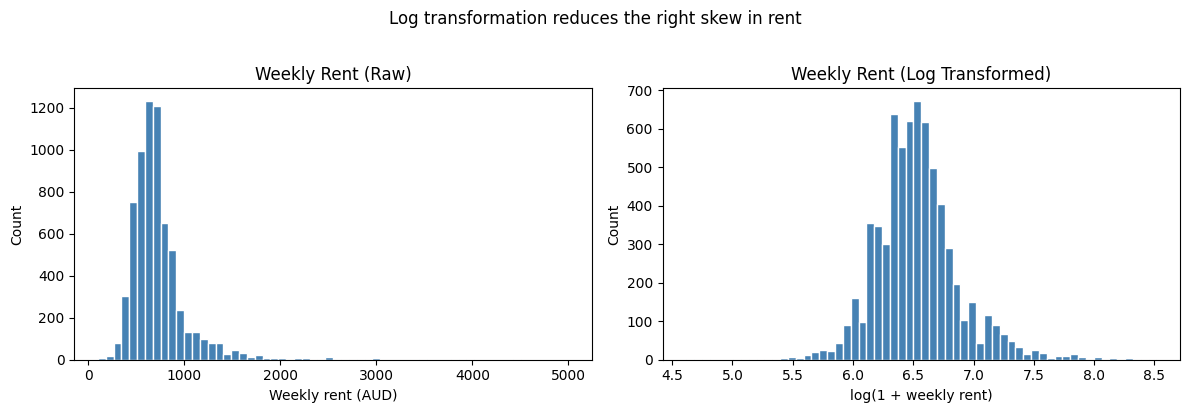

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price_display"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Weekly Rent (Raw)")
axes[0].set_xlabel("Weekly rent (AUD)")
axes[0].set_ylabel("Count")

axes[1].hist(df["log_price"], bins=60, color="steelblue", edgecolor="white")
axes[1].set_title("Weekly Rent (Log Transformed)")
axes[1].set_xlabel("log(1 + weekly rent)")
axes[1].set_ylabel("Count")

plt.suptitle("Log transformation reduces the right skew in rent", y=1.02)
plt.tight_layout()
plt.show()

### 4.2 Rent by Property Size

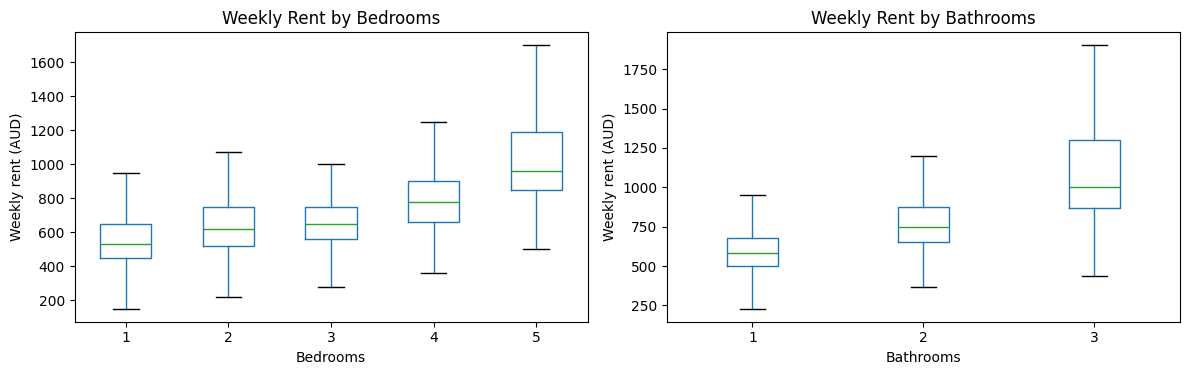

In [67]:
# Limit br / ba to Z = +2
plot_df = df[(df["bedrooms"] <= 5) & (df["bathrooms"] <= 3)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_df.boxplot(column="price_display", by="bedrooms", ax=axes[0], grid=False, showfliers=False)
plot_df.boxplot(column="price_display", by="bathrooms", ax=axes[1], grid=False, showfliers=False)

axes[0].set_title("Weekly Rent by Bedrooms")
axes[0].set_xlabel("Bedrooms")
axes[0].set_ylabel("Weekly rent (AUD)")

axes[1].set_title("Weekly Rent by Bathrooms")
axes[1].set_xlabel("Bathrooms")
axes[1].set_ylabel("Weekly rent (AUD)")

fig.suptitle("")
plt.tight_layout()
plt.show()

### 4.3 Rent by State

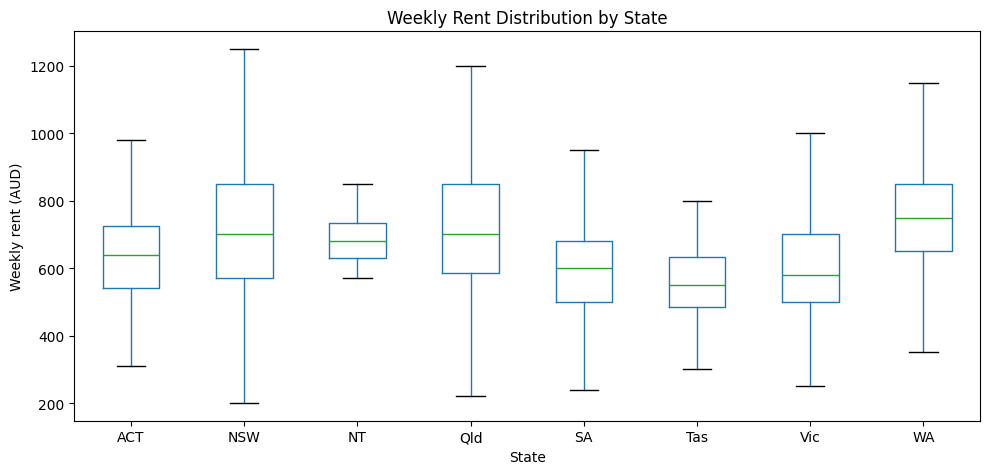

In [68]:
fig, ax = plt.subplots(figsize=(10, 5))

df.boxplot(column="price_display", by="state", ax=ax, grid=False, showfliers=False)

ax.set_title("Weekly Rent Distribution by State")
ax.set_xlabel("State")
ax.set_ylabel("Weekly rent (AUD)")

plt.suptitle("")
plt.tight_layout()
plt.show()

### 4.4 Rent by Amenity (Unadjusted)

This chart shows simple average rent differences by amenity. These are raw comparisons only. For example, listings with a pool may also be larger or located in more expensive areas. Later models control for size and location to see whether specific amenities still appear to matter after accounting for those factors.

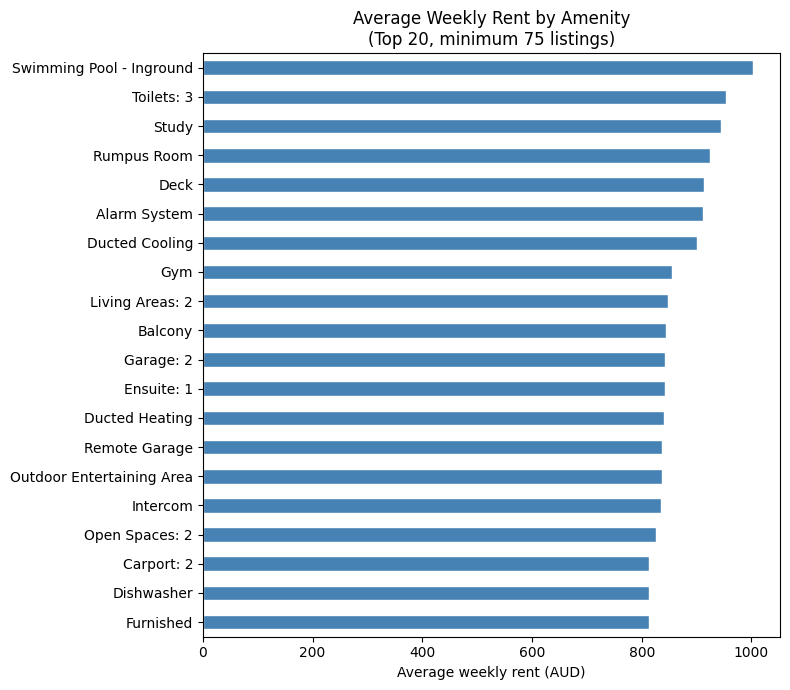

In [69]:
# Splits the amenity field into a list of amenities
amenity_lists = df["amenities"].str.split(",")

rows = []
# Generates a rent, ameninty pair
for i in range(len(df)):
    rent = df.loc[i, "price_display"]
    amenities = amenity_lists.iloc[i]

    for amenity in amenities:
        amenity = amenity.strip()

        if amenity != "":
            rows.append([amenity, rent])

amenity_df = pd.DataFrame(rows, columns=["amenity", "price_display"])

min_count = 75

amenity_stats = []
unique_amenities = amenity_df["amenity"].unique()

# Determines mean rent by unique amenity
for amenity in unique_amenities:
    rows_for_amenity = amenity_df[amenity_df["amenity"] == amenity]
    count = len(rows_for_amenity)

    if count >= min_count:
        avg_rent = rows_for_amenity["price_display"].mean()
        amenity_stats.append([amenity, count, avg_rent])

amenity_summary = pd.DataFrame( amenity_stats, columns=["amenity", "count", "avg_rent"])

amenity_summary = amenity_summary.sort_values(by="avg_rent", ascending=False)
amenity_summary = amenity_summary.head(20)

# Plots to 20 mean rent by amenity in descending order
fig, ax = plt.subplots(figsize=(8, 7))

amenity_summary.sort_values(by="avg_rent").plot( kind="barh", x="amenity",
    y="avg_rent", color="steelblue", edgecolor="white", ax=ax, legend=False)

ax.set_title(f"Average Weekly Rent by Amenity\n(Top 20, minimum {min_count} listings)")
ax.set_xlabel("Average weekly rent (AUD)")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

### 4.5 Distribution of Amenity Counts

Before incorporating amenity richness into the model, it is helpful to understand how many amenities listings typically contain. The chart below shows the distribution of amenity_count, defined as the total number of amenities listed for each property.

This provides context for later analysis in H5, where amenity_count is introduced as a variable capturing the general richness of a listing. Properties with more amenities may command higher rents simply because they are more fully featured overall, rather than because of any single amenity.

Understanding this distribution helps interpret the results of the H5 model, which separates the general premium associated with feature-rich listings from the effects of specific amenities.

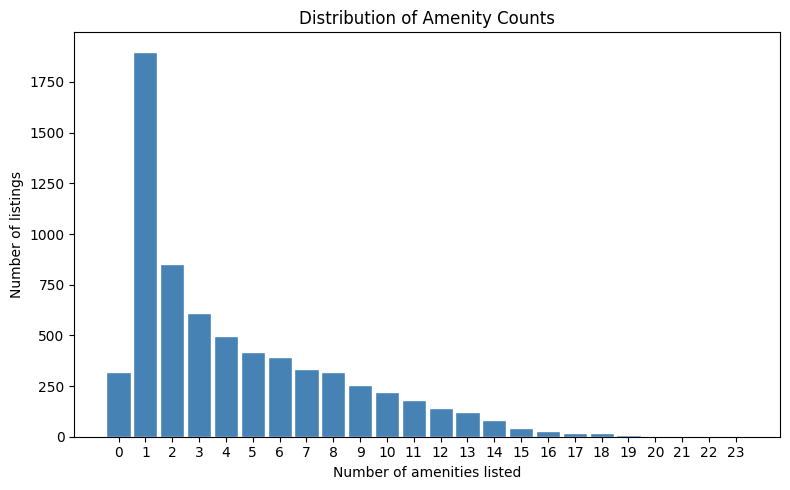

In [70]:
# 4.5 Distribution of amenity counts

amenity_lists = df["amenities"].str.split(",")

amenity_counts = []

# Count number of amenities per listing
for i in range(len(df)):
    amenities = amenity_lists.iloc[i]
    count = 0

    for amenity in amenities:
        amenity = amenity.strip()

        if amenity != "":
            count += 1

    amenity_counts.append(count)

# Plot histogram
max_count = max(amenity_counts)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(amenity_counts,bins=range(0, max_count + 2),align="left",color="steelblue",edgecolor="white",rwidth=0.9)

ax.set_title("Distribution of Amenity Counts")
ax.set_xlabel("Number of amenities listed")
ax.set_ylabel("Number of listings")
ax.set_xticks(range(0, max_count + 1))

plt.tight_layout()
plt.show()

## 5. Hypotheses

To understand what drives rent, I built the model in stages. Each stage adds a new group of variables and tests whether they improve predictive performance.

---

**H1 Property fundamentals explain much of rent variation**

Bedrooms, bathrooms, parking spaces, and property type should explain a large share of the variation in rent. I test this by building a baseline model using only these features. Model performance is evaluated on a held-out test set using MAE_log, and R2_log.

**H2 Location adds important information**

Properties with similar features can still rent for very different prices depending on where they are located. To capture this, I add geographic features (state and postcode) to the fundamentals model and measure whether predictive performance improves.

**H3 Amenities improve the model further**

Amenities such as pools, gyms, or air conditioning may also affect rent. In this step, I add amenity features to the model and test whether they improve performance beyond property size and location.

**H4 Which amenities are associated with higher rent?**

After controlling for property size and location, some amenities may still be associated with higher or lower rent. Using Lasso regularization allows the model to shrink unimportant amenities toward zero and highlight the ones that appear to matter most.

**H5 Amenity Richness Adjustment**

Finally, I examine whether the effects of individual amenities persist after controlling for overall listing richness. An amenity_count variable is introduced to represent the total number of amenities listed for each property, capturing the general premium associated with feature-rich listings. The Lasso model is then refit using this additional variable, allowing us to distinguish between the value of specific amenities and the broader effect of properties that simply offer more amenities overall.

---

### Future Work

**H6 Listing description language**

Listing descriptions may contain information that is not captured by structured fields. A possible extension would be to analyze the description text using TF-IDF and examine whether certain words or phrases are associated with listings that rent above or below model predictions.

## 6. Modeling

### H1 Fundamentals Drive Rent

First, I build a baseline model using only basic property characteristics: bedrooms, bathrooms, parking spaces, and property type. At this stage, the model does not include location or amenities. The goal is to see how much variation in rent can be explained by the physical characteristics of the property alone.

Model performance is evaluated on a held-out test set using **MAE_log** and **R2_log**.

**Why use regularization instead of ordinary linear regression?**

Even with this simple feature set, the model includes categorical variables that are converted into multiple indicator columns, such as property type. Regularization helps prevent the model from overfitting these features.

Two regularized linear models are used:

- **Ridge regression** shrinks coefficients toward zero but keeps all variables in the model. This is useful when many variables each contribute a small amount of signal.
- **Lasso regression** can shrink some coefficients all the way to zero. This acts as a form of feature selection and can help identify which variables appear to matter most.

The regularization strength lambda (alpha) is selected using 5-fold cross-validation, choosing the value that produces the lowest mean absolute error.

**Expected outcome**

I expect bedrooms, bathrooms, and parking spaces to be positively associated with rent. If fundamentals alone explain a meaningful share of the variation in rent, that supports H1 and establishes a baseline for later models that add location and amenities.

### Cross-Validated Model Fitting

The function below is used throughout the analysis to fit either a Ridge or Lasso regression model while selecting the best regularization strength (alpha).

For each candidate alpha value, the training data is split into 5 folds. The model is trained on 4 folds and validated on the remaining fold, repeating this process until every fold has been used once as the validation set. The mean absolute error (MAE) is calculated for each fold, and the average MAE across all folds is used to evaluate that alpha value.

The alpha with the lowest average cross-validation MAE is selected. After that, the model is refit on the full training set using the best alpha and then evaluated once on the held-out test set.

This approach is used repeatedly in H1 through H5 so that model tuning is consistent across all stages of the analysis.

In [71]:
# ------------------------------------------------------------
# Fit a regularized regression model using manual k-fold
# cross-validation to select the best alpha value.
#
# For each candidate alpha:
# 1. Split the training data into k folds
# 2. Train on k-1 folds and validate on the remaining fold
# 3. Compute the MAE for each fold
# 4. Average the fold MAEs
# 5. Keep the alpha with the lowest average CV MAE
#
# After selecting the best alpha, fit the final model on the
# full training set and evaluate it on the held-out test set.
# ------------------------------------------------------------
def fit_model_with_cv(model_type, X_train, y_train, X_test, y_test, alpha_values, kf, state_train):
    best_alpha = None
    best_cv_mae = None

    for alpha in alpha_values:
        fold_maes = []

        for train_index, val_index in kf.split(X_train, state_train):
            X_fold_train = X_train.iloc[train_index]
            X_fold_val = X_train.iloc[val_index]
            y_fold_train = y_train.iloc[train_index]
            y_fold_val = y_train.iloc[val_index]

            if model_type == "ridge":
                model = Ridge(alpha=alpha)
            elif model_type == "lasso":
                model = Lasso(alpha=alpha, max_iter=10000)

            model.fit(X_fold_train, y_fold_train)

            val_predictions = model.predict(X_fold_val)
            fold_mae = mean_absolute_error(y_fold_val, val_predictions)
            fold_maes.append(fold_mae)

        mean_cv_mae = np.mean(fold_maes)
        print(f"{model_type.title()} alpha={alpha}: CV MAE = {mean_cv_mae:.4f}")

        if best_cv_mae is None or mean_cv_mae < best_cv_mae:
            best_cv_mae = mean_cv_mae
            best_alpha = alpha

    if model_type == "ridge":
        best_model = Ridge(alpha=best_alpha)
    elif model_type == "lasso":
        best_model = Lasso(alpha=best_alpha, max_iter=10000)

    best_model.fit(X_train, y_train)

    # Predictions on log scale
    test_predictions = best_model.predict(X_test)

    # Metrics on log scale
    test_mae_log = mean_absolute_error(y_test, test_predictions)
    test_r2_log = r2_score(y_test, test_predictions)

    # Convert both actual and predicted values back to rent scale
    y_test_rent = np.expm1(y_test)
    test_predictions_rent = np.expm1(test_predictions)

    # Metrics on original rent scale
    test_mae_rent = mean_absolute_error(y_test_rent, test_predictions_rent)
    test_r2_rent = r2_score(y_test_rent, test_predictions_rent)

    return best_model, best_alpha, best_cv_mae, test_mae_log, test_r2_log, test_mae_rent, test_r2_rent


In [72]:
# Features for the fundamentals model 
X = df[["bedrooms", "bathrooms", "parking_spaces","propertyType"]].copy()
# Target for the fundamentals model
y = df["log_price"].copy()

# Convert propertyType into dummy columns with 0/1 values
X = pd.get_dummies(X, columns=["propertyType"])

# Generates a training set and test set. 
# Default value of test size is used (0.25).
# Random_state is fixed for reproducibility
# Sets are stratified by state to ensure equal distribution between sets.
X_train, X_test, y_train, y_test, state_train, state_test = train_test_split(X, y, df["state"], random_state=1, stratify=df["state"])

# Candidate alpha values
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# 5-fold cross-validation setup
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

print(f"Training rows: {len(X_train)}")
print(f"Test rows: {len(X_test)}")

Training rows: 5074
Test rows: 1692


In [73]:
# Stores final results
results = []

# Ridge regression
best_ridge_model, best_ridge_alpha, best_ridge_cv_mae, ridge_mae_log, ridge_r2_log, ridge_mae_rent, ridge_r2_rent = fit_model_with_cv(
    "ridge", X_train, y_train, X_test, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha: {best_ridge_alpha}\n")
results.append(["Ridge", ridge_mae_log, ridge_r2_log, ridge_mae_rent, ridge_r2_rent])

# Lasso regression
best_lasso_model, best_lasso_alpha, best_lasso_cv_mae, lasso_mae_log, lasso_r2_log, lasso_mae_rent, lasso_r2_rent = fit_model_with_cv(
    "lasso", X_train, y_train, X_test, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha: {best_lasso_alpha}\n")
results.append(["Lasso", lasso_mae_log, lasso_r2_log, lasso_mae_rent, lasso_r2_rent])

# Results table
results_df = pd.DataFrame( results, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_df)

Ridge alpha=0.001: CV MAE = 0.1967
Ridge alpha=0.01: CV MAE = 0.1967
Ridge alpha=0.1: CV MAE = 0.1967
Ridge alpha=1: CV MAE = 0.1967
Ridge alpha=10: CV MAE = 0.1966
Ridge alpha=100: CV MAE = 0.1969

Best Ridge alpha: 10

Lasso alpha=0.001: CV MAE = 0.1967
Lasso alpha=0.01: CV MAE = 0.1989
Lasso alpha=0.1: CV MAE = 0.2368
Lasso alpha=1: CV MAE = 0.2556
Lasso alpha=10: CV MAE = 0.2556
Lasso alpha=100: CV MAE = 0.2556

Best Lasso alpha: 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.198994,0.371587,162.459435,0.235869
1,Lasso,0.199032,0.370532,162.546732,0.233318


### H1 Results

The fundamentals-only model provides a useful baseline, but its predictive power is limited. Using only bedrooms, bathrooms, parking spaces, and property type, Ridge and Lasso perform almost identically.

For Ridge, the best regularization strength selected by 5-fold cross-validation was **alpha = 10**, with a test-set performance of **MAE_log = 0.1990** and **R2_log = 0.3716**. On the original rent scale, this corresponds to **MAE_rent = 162.46 AUD per week** and **R2_rent = 0.2359**.

Lasso selected **alpha = 0.001** and produced nearly the same results: **MAE_log = 0.1990**, **R2_log = 0.3705**, **MAE_rent = 162.55 AUD per week**, and **R2_rent = 0.2333**.

These results suggest that property fundamentals alone explain a meaningful but limited share of rental price variation. This supports H1 in the sense that physical characteristics do matter, but it also indicates that fundamentals by themselves are not sufficient to capture most of the structure in rent. That makes location and amenities natural next additions to the model.

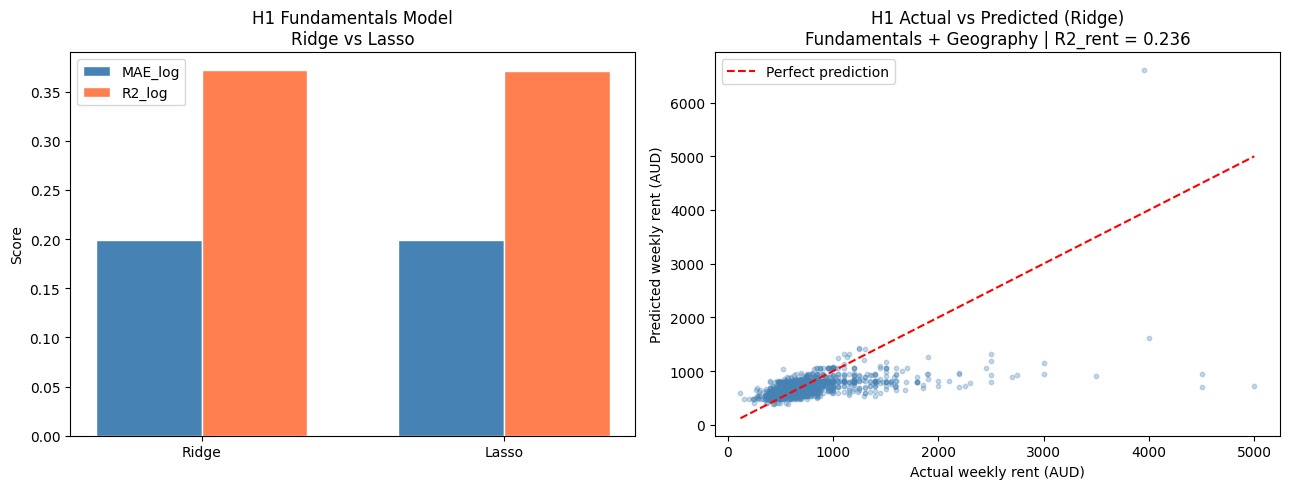

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ridge vs Lasso
plot_df = results_df.set_index("model")

models = plot_df.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar( x - width / 2, plot_df["MAE_log"], width, label="MAE_log", color="steelblue", edgecolor="white" )

axes[0].bar( x + width / 2, plot_df["R2_log"], width, label="R2_log", color="coral", edgecolor="white" )
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H1 Fundamentals Model\nRidge vs Lasso")
axes[0].set_ylabel("Score")
axes[0].legend()

# Ridge performance
ridge_predictions = best_ridge_model.predict(X_test)

y_test_rent = np.expm1(y_test)
ridge_predictions_rent = np.expm1(ridge_predictions)

axes[1].scatter(y_test_rent, ridge_predictions_rent, alpha=0.3, color="steelblue", s=10)
axes[1].plot([y_test_rent.min(), y_test_rent.max()], [y_test_rent.min(), y_test_rent.max()],"r--", linewidth=1.5, label="Perfect prediction")

axes[1].set_title( "H1 Actual vs Predicted (Ridge)\n"
    f"Fundamentals + Geography | R2_rent = {ridge_r2_rent:.3f}")

axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend()

plt.tight_layout()
plt.show()

### H1 Visualization Summary

The chart on the left shows that Ridge and Lasso perform almost identically when only the basic property features are used. This indicates that bedrooms, bathrooms, parking spaces, and property type contain useful predictive signal, but by themselves they explain only a limited share of the overall variation in rent.

The chart on the right shows that the Ridge model captures the general relationship between fundamentals and rent, but the predictions are compressed toward the middle of the rent distribution. Lower-rent listings are often predicted somewhat too high, while higher-rent listings are often predicted too low. This pattern suggests that important sources of variation, especially location and amenities, are still missing from the model.

### H2 Geography Adds Substantial Explanatory Power

Next I add geographic information to the model by including state and postcode as predictors. This tests whether knowing where a property is located explains additional variation in rent beyond what the property's physical characteristics can explain.

State captures broad regional differences in rent levels across Australia. postcode provides much more detailed geographic information, representing neighborhood-level pricing. The dataset contains 1,093 unique postcodes, so converting this variable to dummy indicators introduces a large number of additional predictors.

**Why this matters for the model**

Adding many postcode indicators greatly expands the feature space. This is exactly the situation where regularization becomes useful. Ridge can stabilize the model by shrinking many postcode coefficients, while Lasso may set some coefficients to zero if those neighborhoods do not provide meaningful additional signal.

If location strongly influences rent, we should see a noticeable improvement in model performance compared with the fundamentals-only model.

**Same train/test split as H1**

To make the results comparable, the same train/test split used in H1 is reused here. This allows us to directly measure how much predictive performance improves after adding geographic information.

In [75]:
# Features now include fundamentals + geography (state, postcode)
X_geo = df[[ "bedrooms", "bathrooms", "parking_spaces", "propertyType",
            "state", "postcode"]].copy()

# Convert categorical variables to dummy indicators
X_geo = pd.get_dummies(X_geo, columns=["propertyType", "state", "postcode"])

# Recreate the same train/test split used in H1
X_train_geo, X_test_geo, y_train, y_test, state_train, state_test = train_test_split(
    X_geo, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_geo)}")
print(f"Test rows: {len(X_test_geo)}")

Training rows: 5074
Test rows: 1692


In [76]:
results_geo = []

# Ridge regression
best_ridge_geo, best_ridge_alpha_geo, best_ridge_cv_mae_geo, ridge_mae_log_geo, ridge_r2_log_geo, ridge_mae_rent_geo, ridge_r2_rent_geo = fit_model_with_cv(
    "ridge", X_train_geo, y_train, X_test_geo, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H2): {best_ridge_alpha_geo}\n")
results_geo.append(["Ridge", ridge_mae_log_geo, ridge_r2_log_geo, ridge_mae_rent_geo, ridge_r2_rent_geo])

# Lasso regression
best_lasso_geo, best_lasso_alpha_geo, best_lasso_cv_mae_geo, lasso_mae_log_geo, lasso_r2_log_geo, lasso_mae_rent_geo, lasso_r2_rent_geo = fit_model_with_cv(
    "lasso", X_train_geo, y_train, X_test_geo, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H2): {best_lasso_alpha_geo}\n")
results_geo.append(["Lasso", lasso_mae_log_geo, lasso_r2_log_geo, lasso_mae_rent_geo, lasso_r2_rent_geo])

# Results table
results_h2_df = pd.DataFrame(results_geo, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h2_df)

Ridge alpha=0.001: CV MAE = 0.1358
Ridge alpha=0.01: CV MAE = 0.1357
Ridge alpha=0.1: CV MAE = 0.1346
Ridge alpha=1: CV MAE = 0.1344
Ridge alpha=10: CV MAE = 0.1575
Ridge alpha=100: CV MAE = 0.1798

Best Ridge alpha (H2): 1

Lasso alpha=0.001: CV MAE = 0.1801
Lasso alpha=0.01: CV MAE = 0.1935
Lasso alpha=0.1: CV MAE = 0.2368
Lasso alpha=1: CV MAE = 0.2556
Lasso alpha=10: CV MAE = 0.2556
Lasso alpha=100: CV MAE = 0.2556

Best Lasso alpha (H2): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.136747,0.664532,115.547638,0.524039
1,Lasso,0.185438,0.452949,152.346271,0.316142


### H2 Results

Adding geography produces a major improvement over the fundamentals-only baseline, especially for Ridge regression. With state and postcode included, Ridge selected **alpha = 1** and achieved **MAE_log = 0.1367** and **R2_log = 0.6645** on the held-out test set. On the original rent scale, this corresponds to **MAE_rent = 115.55 AUD per week** and **R2_rent = 0.5240**.

Lasso again selected **alpha = 0.001**, but its performance was substantially weaker: **MAE_log = 0.1854**, **R2_log = 0.4529**, **MAE_rent = 152.35 AUD per week**, and **R2_rent = 0.3161**.

Compared with H1, these results show that geography adds a large amount of explanatory power. The jump in Ridge performance suggests that location is far more informative than fundamentals alone for explaining rental prices. Ridge clearly outperforms Lasso in this setting, which is consistent with geographic signal being spread across many correlated location indicators rather than concentrated in a small sparse subset.

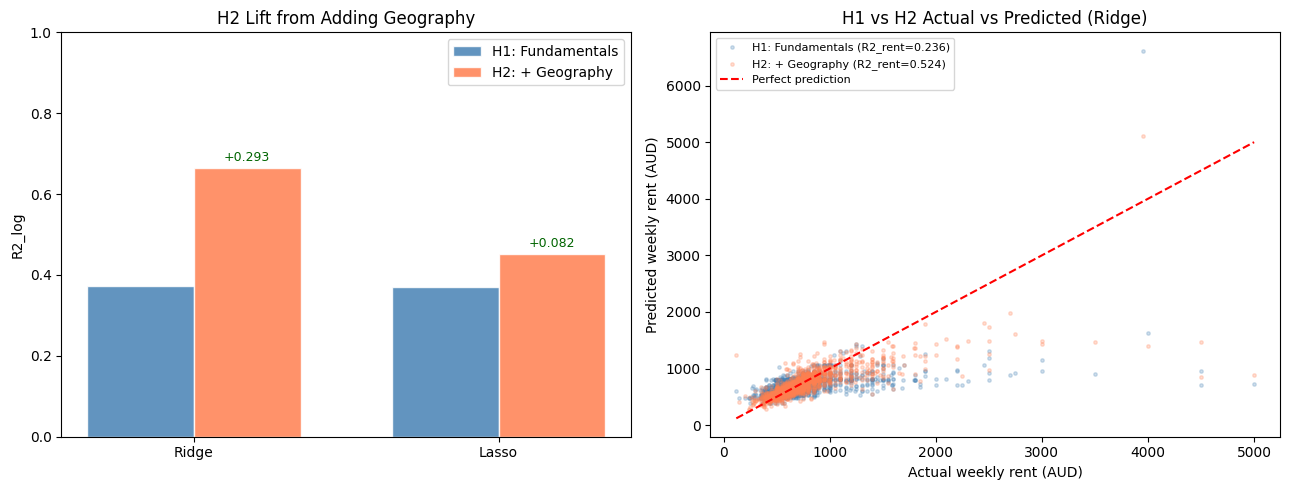

In [77]:
# --- Visualization: H1 vs H2 lift + actual vs predicted ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: H1 vs H2 R2 comparison
h1_r2 = results_df["R2_log"].values
h2_r2 = results_h2_df["R2_log"].values
models = ["Ridge", "Lasso"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width / 2,h1_r2,width,label="H1: Fundamentals",
    color="steelblue",edgecolor="white",alpha=0.85)

axes[0].bar(x + width / 2,h2_r2,width,label="H2: + Geography",
            color="coral",edgecolor="white",alpha=0.85)

# Compute the improvement in R2 from H1 to H2
r2_lift = h2_r2 - h1_r2

# Add the improvement labels above the H2 bars
for i in range(len(r2_lift)):
    lift_value = r2_lift[i]
    x_position = x[i] + width / 2
    y_position = h2_r2[i] + 0.01
    label_text = f"+{lift_value:.3f}"
    axes[0].annotate(label_text,xy=(x_position, y_position),
        ha="center",va="bottom",fontsize=9,color="darkgreen")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H2 Lift from Adding Geography")
axes[0].set_ylabel("R2_log")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: H1 vs H2 actual vs predicted (Ridge)
ridge_h1_predictions = best_ridge_model.predict(X_test)
ridge_h2_predictions = best_ridge_geo.predict(X_test_geo)

y_test_rent = np.expm1(y_test)
ridge_h1_predictions_rent = np.expm1(ridge_h1_predictions)
ridge_h2_predictions_rent = np.expm1(ridge_h2_predictions)

axes[1].scatter(y_test_rent,ridge_h1_predictions_rent,
    alpha=0.25,color="steelblue",s=6,label=f"H1: Fundamentals (R2_rent={ridge_r2_rent:.3f})")

axes[1].scatter(y_test_rent,ridge_h2_predictions_rent,
    alpha=0.25,color="coral",s=6,label=f"H2: + Geography (R2_rent={ridge_r2_rent_geo:.3f})")

axes[1].plot([y_test_rent.min(), y_test_rent.max()],[y_test_rent.min(), y_test_rent.max()],
    "r--",linewidth=1.5,label="Perfect prediction")

axes[1].set_title("H1 vs H2 Actual vs Predicted (Ridge)")
axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H2 Visualization Summary

Adding geography produces the largest performance jump in the entire project. Ridge **R2_log** increases from **0.372** in H1 to **0.665** in H2, while Lasso improves from **0.371** to **0.453**. This shows that location contributes far more explanatory power than property fundamentals alone.

The scatter plot shows a clear improvement in prediction accuracy after geography is added. The H2 Ridge predictions align much more closely with the diagonal reference line, indicating that the model captures a much larger share of the variation in rent. Overall, these results confirm that geography is the dominant driver of rental price in the dataset.

### H3 Amenities Improve the Model Further

Now I add amenities to the model along with the fundamentals and geography features. The goal is to test whether amenities help explain rent beyond the size of the property and where it is located.

**How amenities are handled**

The amenities column is stored as comma-separated text, so I first split it into individual amenities. Blank values are removed, and then dummy columns are created so each amenity becomes a 0 or 1 feature showing whether the listing includes it.

**Why this comes after H2**

Amenities are added after geography so their effect can be measured more clearly. That way, any improvement in performance from H2 to H3 can be attributed to the amenity features.

**Expectations**

Amenities should improve the model, but probably by less than geography did. Location already explained a large share of rent variation in H2. I also expect Lasso to be more useful here, because amenity effects are more likely to be sparse.

In [78]:
# Add amenity features

# Clean the amenities text before creating dummy columns
def clean_amenity_text(text):
    items = text.split(",")
    cleaned_items = []
    for item in items:
        item = item.strip().lower()
        if item != "":
            cleaned_items.append(item)
    return ",".join(cleaned_items)

clean_amenities = df["amenities"].apply(clean_amenity_text)

# Create dummy columns from the cleaned text
amenity_dummies = clean_amenities.str.get_dummies(sep=",")

# Drop blank amenity column
amenity_dummies = amenity_dummies.loc[:, amenity_dummies.columns != ""]

# Combine the amenity columns with the feature set from H2
X_h3 = pd.concat([X_geo.copy(), amenity_dummies], axis=1)

y = df["log_price"].copy()

X_train_h3, X_test_h3, y_train, y_test, state_train, state_test = train_test_split(
    X_h3, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_h3)}")
print(f"Test rows: {len(X_test_h3)}")
print(f"Total features in H3: {X_h3.shape[1]}")
print("Duplicate amenity columns:", amenity_dummies.columns.duplicated().sum())

Training rows: 5074
Test rows: 1692
Total features in H3: 1197
Duplicate amenity columns: 0


In [79]:
results_h3 = []

# Ridge regression
best_ridge_h3, best_ridge_alpha_h3, best_ridge_cv_mae_h3, ridge_mae_log_h3, ridge_r2_log_h3, ridge_mae_rent_h3, ridge_r2_rent_h3 = fit_model_with_cv(
    "ridge", X_train_h3, y_train, X_test_h3, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H3): {best_ridge_alpha_h3}\n")
results_h3.append(["Ridge", ridge_mae_log_h3, ridge_r2_log_h3, ridge_mae_rent_h3, ridge_r2_rent_h3])

# Lasso regression
best_lasso_h3, best_lasso_alpha_h3, best_lasso_cv_mae_h3, lasso_mae_log_h3, lasso_r2_log_h3, lasso_mae_rent_h3, lasso_r2_rent_h3 = fit_model_with_cv(
    "lasso", X_train_h3, y_train, X_test_h3, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H3): {best_lasso_alpha_h3}\n")
results_h3.append(["Lasso", lasso_mae_log_h3, lasso_r2_log_h3, lasso_mae_rent_h3, lasso_r2_rent_h3])

# Results table
results_h3_df = pd.DataFrame(results_h3, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h3_df)

Ridge alpha=0.001: CV MAE = 0.1353
Ridge alpha=0.01: CV MAE = 0.1352
Ridge alpha=0.1: CV MAE = 0.1338
Ridge alpha=1: CV MAE = 0.1332
Ridge alpha=10: CV MAE = 0.1543
Ridge alpha=100: CV MAE = 0.1747

Best Ridge alpha (H3): 1

Lasso alpha=0.001: CV MAE = 0.1754
Lasso alpha=0.01: CV MAE = 0.1923
Lasso alpha=0.1: CV MAE = 0.2368
Lasso alpha=1: CV MAE = 0.2556
Lasso alpha=10: CV MAE = 0.2556
Lasso alpha=100: CV MAE = 0.2556

Best Lasso alpha (H3): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.131626,0.684663,111.627168,0.541766
1,Lasso,0.178114,0.488357,146.352766,0.358616


### H3 Results: Amenities Add Signal, But Geography Dominates

**Finding: H3 is validated, but the lift is modest.**

Adding amenities on top of fundamentals and geography produces a further improvement in predictive performance, with Ridge again emerging as the stronger model. Ridge selected **alpha = 1** and achieved **MAE_log = 0.1316** and **R2_log = 0.6847** on the held-out test set. On the original rent scale, this corresponds to **MAE_rent = 111.63 AUD per week** and **R2_rent = 0.5418**.

Lasso selected **alpha = 0.001**, but remained substantially weaker: **MAE_log = 0.1781**, **R2_log = 0.4884**, **MAE_rent = 146.35 AUD per week**, and **R2_rent = 0.3586**.

Compared with H2, the Ridge improvement is smaller than the jump produced by geography, but it is still meaningful and consistent. This suggests that amenities add incremental predictive value beyond property fundamentals and location. Ridge continues to outperform Lasso, which is consistent with amenity signal being distributed across many correlated features rather than concentrated in only a few sparse effects.

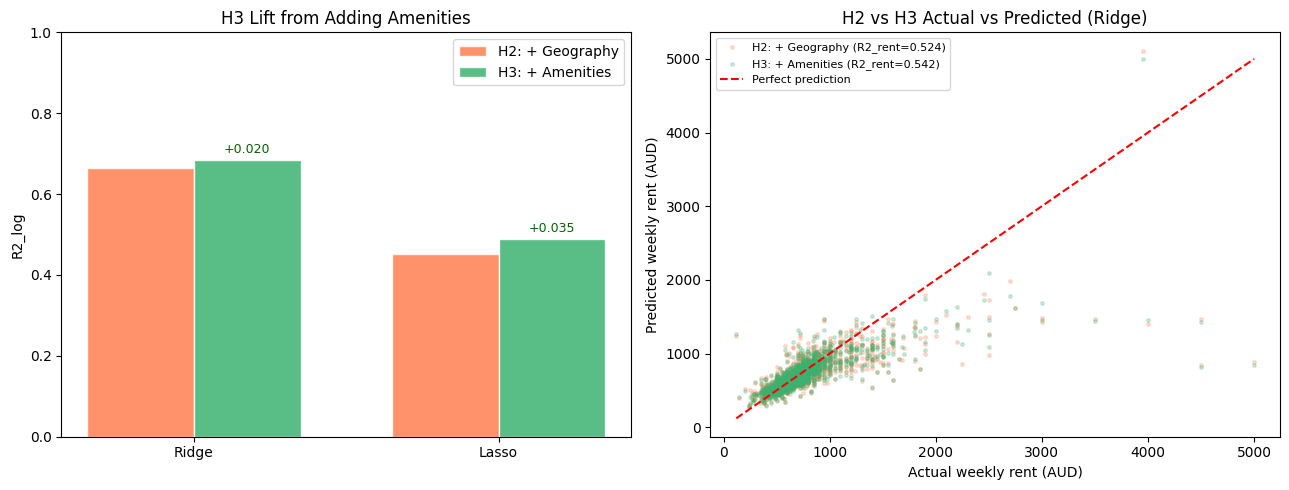

In [80]:
#H2 vs H3 lift + actual vs predicted
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: H2 vs H3 R2 comparison
h2_r2 = results_h2_df["R2_log"].values
h3_r2 = results_h3_df["R2_log"].values
models = ["Ridge", "Lasso"]
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width / 2,h2_r2,width,label="H2: + Geography",
    color="coral",edgecolor="white",alpha=0.85)

axes[0].bar(x + width / 2,h3_r2,width,label="H3: + Amenities",
            color="mediumseagreen",edgecolor="white",alpha=0.85)

# Compute the improvement in R2 from H2 to H3
r2_lift = h3_r2 - h2_r2

# Add the improvement labels above the H3 bars
for i in range(len(r2_lift)):
    lift_value = r2_lift[i]
    x_position = x[i] + width / 2
    y_position = h3_r2[i] + 0.01
    label_text = f"+{lift_value:.3f}"
    axes[0].annotate(label_text,xy=(x_position, y_position),
        ha="center",va="bottom",fontsize=9,color="darkgreen")

axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("H3 Lift from Adding Amenities")
axes[0].set_ylabel("R2_log")
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right: H2 vs H3 actual vs predicted (Ridge)
ridge_h2_predictions = best_ridge_geo.predict(X_test_geo)
ridge_h3_predictions = best_ridge_h3.predict(X_test_h3)

y_test_rent = np.expm1(y_test)
ridge_h2_predictions_rent = np.expm1(ridge_h2_predictions)
ridge_h3_predictions_rent = np.expm1(ridge_h3_predictions)

axes[1].scatter(y_test_rent,ridge_h2_predictions_rent,
    alpha=0.25,color="coral",s=6,label=f"H2: + Geography (R2_rent={ridge_r2_rent_geo:.3f})")

axes[1].scatter(y_test_rent,ridge_h3_predictions_rent,
    alpha=0.25,color="mediumseagreen",s=6,label=f"H3: + Amenities (R2_rent={ridge_r2_rent_h3:.3f})")

axes[1].plot([y_test_rent.min(), y_test_rent.max()],[y_test_rent.min(), y_test_rent.max()],
    "r--",linewidth=1.5,label="Perfect prediction")

axes[1].set_title("H2 vs H3 Actual vs Predicted (Ridge)")
axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

### H3 Visualization Summary

Adding amenities produces a modest but consistent improvement in model performance. Ridge **R2_log** increases from **0.665** to **0.685**, while Lasso improves from **0.453** to **0.488**, confirming that amenities provide additional predictive signal beyond fundamentals and geography.

The scatter plot shows only a slight tightening around the diagonal after amenities are added, which is consistent with the relatively small performance gain. This indicates that amenities improve prediction accuracy, but the effect is much smaller than the improvement produced by geography. Overall, location remains the primary driver of rent, while amenities provide incremental refinement.

### H4 Individual Amenity Effects are Quantifiable

H3 showed that amenities improve the model overall. In H4, I look more closely at the individual amenity features to see which ones are most strongly associated with higher or lower rent.

To do this, I examine the coefficients from the Lasso model trained on the full feature set. These coefficients help identify the direction and relative size of each amenity’s association with rent after controlling for property fundamentals and geography.

**Why Lasso is useful here**

Ridge performed better for prediction, but it keeps every feature in the model with a small coefficient. This makes it harder to interpret which amenities matter most.

Lasso applies an L1 penalty, which shrinks some coefficients toward zero and can eliminate weaker features entirely. This produces a shorter list of amenities with non-zero coefficients, making it easier to interpret which amenities are most strongly associated with higher or lower rent.

**How to interpret the coefficients**

The model predicts log(1 + rent), so the coefficients are on the log scale. To make them easier to interpret, I convert them to approximate percentage differences using:

% difference = 100 × (e^β - 1)

For example, a coefficient of 0.05 corresponds to roughly a 5% higher predicted rent, controlling for the other included features.

Positive coefficients indicate amenities associated with higher rent, while negative coefficients indicate amenities associated with lower rent.

**Expected Outcome**

Premium amenities such as pools, parking features, or upgraded climate control systems may show positive associations. Amenities that are very common across listings may have small or near-zero coefficients because they do not strongly differentiate higher-priced properties.

In [81]:
# H4: Extract amenity coefficients from the H3 Lasso model

# Put feature names and coefficients together in one table
coef_df = pd.DataFrame({"feature": X_train_h3.columns, "coef_log": best_lasso_h3.coef_})

# Keep only amenity features (removes all the features from h3 that existed in h2)
h2_features = set(X_geo.columns)
amenity_df = coef_df[~coef_df["feature"].isin(h2_features)].copy()

# Convert log-scale coefficients to approximate percent effects
amenity_df["pct_effect"] = (np.exp(amenity_df["coef_log"]) - 1) * 100

# Clean up names for display
amenity_df["amenity"] = amenity_df["feature"]

# Split into positive, negative, and zero coefficients
premium_amenities = amenity_df[amenity_df["coef_log"] > 0].copy()
discount_amenities = amenity_df[amenity_df["coef_log"] < 0].copy()
zeroed_amenities = amenity_df[amenity_df["coef_log"] == 0].copy()

# Sort for easier reading
premium_amenities = premium_amenities.sort_values(by="coef_log", ascending=False)
discount_amenities = discount_amenities.sort_values(by="coef_log", ascending=True)

# Print summary
retained_count = len(amenity_df[amenity_df["coef_log"] != 0])
zeroed_count = len(zeroed_amenities)

print(f"Amenities retained by Lasso: {retained_count}")
print(f"Amenities zeroed out by Lasso: {zeroed_count}")

print("\nTop premium amenities:")
display(premium_amenities[["amenity", "coef_log", "pct_effect"]].head(10).reset_index(drop=True))

print("\nTop discount amenities:")
display(discount_amenities[["amenity", "coef_log", "pct_effect"]].head(10).reset_index(drop=True))

Amenities retained by Lasso: 28
Amenities zeroed out by Lasso: 54

Top premium amenities:


,amenity,coef_log,pct_effect
0,swimming pool - inground,0.112551,11.912958
1,open fireplace,0.059855,6.168283
2,balcony,0.047682,4.883700
3,deck,0.044523,4.552953
4,floorboards,0.040214,4.103318
5,study,0.038491,3.924142
6,outdoor entertaining area,0.037271,3.797468
7,ducted cooling,0.036776,3.746109
8,courtyard,0.030602,3.107552
9,intercom,0.029743,3.018931



Top discount amenities:


,amenity,coef_log,pct_effect
0,fully fenced,-0.051042,-4.976119
1,toilets: 2,-0.024665,-2.436357
2,evaporative cooling,-0.019390,-1.920325
3,toilets: 1,-0.019240,-1.905598
4,split-system air conditioning,-0.019131,-1.894946
5,air conditioning,-0.017907,-1.774807
6,secure parking,-0.006109,-0.609003
7,remote garage,-0.004699,-0.468768
8,ensuite: 1,-0.003766,-0.375936


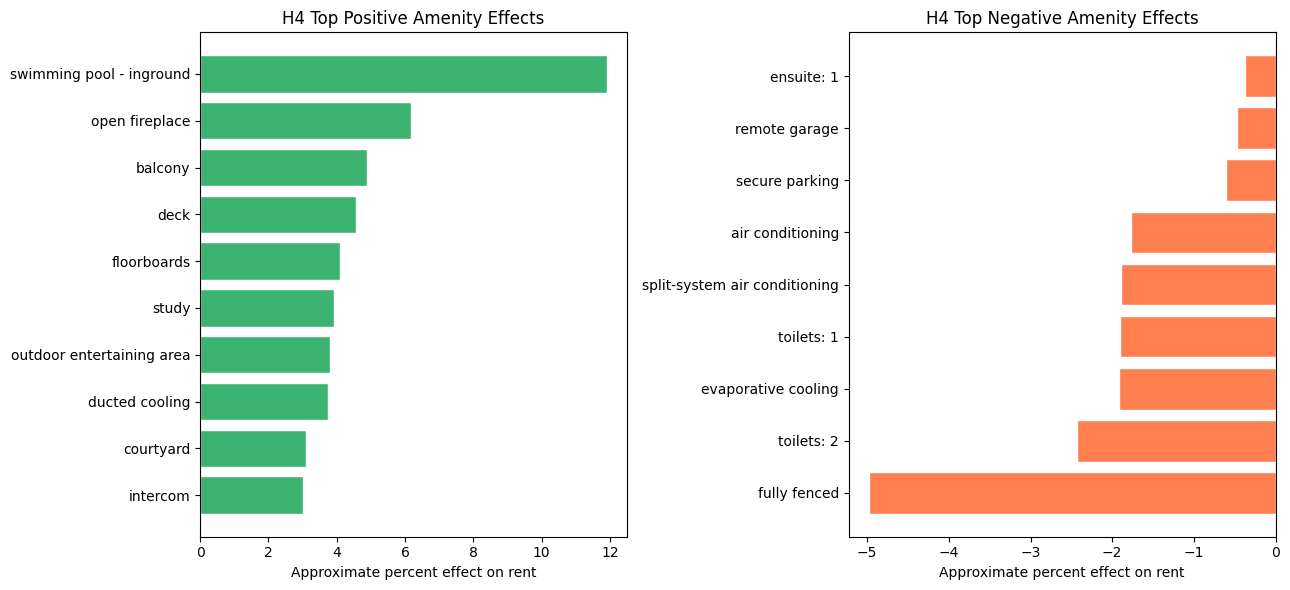

In [82]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Top positive amenity effects
top_positive = premium_amenities.head(10).copy()
top_positive = top_positive.sort_values(by="pct_effect", ascending=True)

axes[0].barh(top_positive["amenity"],top_positive["pct_effect"],
    color="mediumseagreen",edgecolor="white")

axes[0].set_title("H4 Top Positive Amenity Effects")
axes[0].set_xlabel("Approximate percent effect on rent")
axes[0].set_ylabel("")

# Top negative amenity effects
top_negative = discount_amenities.head(10).copy()
top_negative = top_negative.sort_values(by="pct_effect", ascending=True)

axes[1].barh(top_negative["amenity"],top_negative["pct_effect"],color="coral",edgecolor="white")

axes[1].set_title("H4 Top Negative Amenity Effects")
axes[1].set_xlabel("Approximate percent effect on rent")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### H4 Results: Amenity Effects Quantified

The Lasso model retained 28 amenities with non-zero coefficients and set 54 amenities to zero, showing that only some amenities provide distinct predictive signal after controlling for property size and location.

The strongest positive associations were found for premium and lifestyle features such as inground swimming pools, open fireplaces, balconies, decks, and studies. A smaller group of amenities showed negative associations, including fully fenced, evaporative cooling, and split-system air conditioning. In this model, those features are associated with lower predicted rent after controlling for the other included property and geographic characteristics.

Overall, these results suggest that while many amenities appear in listings, only a limited subset meaningfully differentiates higher and lower priced rental properties once geography and core property features are already included in the model.

### H5 Amenity Richness vs. Specific Amenity Effects

H4 identified which individual amenities were associated with higher or lower rent. However, many amenities tend to appear together, properties with more features generally list more amenities overall. This raises an important question:

**Are the premiums we observed driven by specific amenities, or simply by properties being more feature-rich overall?**

To test this, I introduce a new feature: amenity_count, the total number of amenities listed for each property. I then refit the Lasso model from H3 using the full feature set plus this additional variable.

Including amenity_count allows the model to separate two effects:

- **General listing richness:** properties with many amenities may command higher rent simply because they are more fully equipped.

- **Specific amenity value:** certain amenities may still stand out even after controlling for the overall number of amenities.

If amenity_count absorbs much of the signal and many individual amenities are zeroed out, this suggests that the premium observed in H4 was largely driven by general property richness. Conversely, amenities that retain non-zero coefficients after adding amenity_count represent features whose value appears distinct beyond simply having more amenities overall.

In [83]:
# H5: Add amenity count to the H3 feature set

# Count the number of amenities listed for each property
amenity_count = []
for text in df["amenities"]:
    items = text.split(",")
    count = 0
    for item in items:
        item = item.strip()
        if item != "":
            count += 1
    amenity_count.append(count)

# Start with the H3 feature set and add amenity_count
X_h5 = X_h3.copy()
X_h5["amenity_count"] = amenity_count

X_train_h5, X_test_h5, y_train, y_test, state_train, state_test = train_test_split(
    X_h5, y, df["state"], random_state=1, stratify=df["state"])

print(f"Training rows: {len(X_train_h5)}")
print(f"Test rows: {len(X_test_h5)}")
print(f"Total features in H5: {X_h5.shape[1]}")

Training rows: 5074
Test rows: 1692
Total features in H5: 1198


In [84]:
results_h5 = []

# Ridge regression
best_ridge_h5, best_ridge_alpha_h5, best_ridge_cv_mae_h5, ridge_mae_log_h5, ridge_r2_log_h5, ridge_mae_rent_h5, ridge_r2_rent_h5 = fit_model_with_cv(
    "ridge", X_train_h5, y_train, X_test_h5, y_test, alpha_values, kf, state_train)

print(f"\nBest Ridge alpha (H5): {best_ridge_alpha_h5}\n")
results_h5.append(["Ridge", ridge_mae_log_h5, ridge_r2_log_h5, ridge_mae_rent_h5, ridge_r2_rent_h5])

# Lasso regression
best_lasso_h5, best_lasso_alpha_h5, best_lasso_cv_mae_h5, lasso_mae_log_h5, lasso_r2_log_h5, lasso_mae_rent_h5, lasso_r2_rent_h5 = fit_model_with_cv(
    "lasso", X_train_h5, y_train, X_test_h5, y_test, alpha_values, kf, state_train)

print(f"\nBest Lasso alpha (H5): {best_lasso_alpha_h5}\n")
results_h5.append(["Lasso", lasso_mae_log_h5, lasso_r2_log_h5, lasso_mae_rent_h5, lasso_r2_rent_h5])

# Results table
results_h5_df = pd.DataFrame(results_h5, columns=["model", "MAE_log", "R2_log", "MAE_rent", "R2_rent"])
display(results_h5_df)

Ridge alpha=0.001: CV MAE = 0.1354
Ridge alpha=0.01: CV MAE = 0.1352
Ridge alpha=0.1: CV MAE = 0.1339
Ridge alpha=1: CV MAE = 0.1333
Ridge alpha=10: CV MAE = 0.1543
Ridge alpha=100: CV MAE = 0.1745

Best Ridge alpha (H5): 1

Lasso alpha=0.001: CV MAE = 0.1753
Lasso alpha=0.01: CV MAE = 0.1922
Lasso alpha=0.1: CV MAE = 0.2341
Lasso alpha=1: CV MAE = 0.2556
Lasso alpha=10: CV MAE = 0.2556
Lasso alpha=100: CV MAE = 0.2556

Best Lasso alpha (H5): 0.001



,model,MAE_log,R2_log,MAE_rent,R2_rent
0,Ridge,0.131536,0.684913,111.559950,0.542267
1,Lasso,0.177741,0.488658,146.025327,0.359995


#### H5 Lasso Results: Amenity Richness vs. Specific Amenity Effects

H5 produces the strongest overall model performance, although the improvement over H3 is very small. Ridge selected **alpha = 1** and achieved **MAE_log = 0.1315** and **R2_log = 0.6849** on the held-out test set. On the original rent scale, this corresponds to **MAE_rent = 111.56 AUD per week** and **R2_rent = 0.5423**.

Lasso again selected **alpha = 0.001**, but its performance remained substantially weaker: **MAE_log = 0.1777**, **R2_log = 0.4887**, **MAE_rent = 146.03 AUD per week**, and **R2_rent = 0.3600**.

To understand how amenity richness interacts with individual amenities, we repeat the H4 coefficient analysis using the H5 Lasso model. This allows us to examine two things:

- **The coefficient on amenity_count**, which represents the general premium associated with listings that contain more amenities overall.

- **The individual amenity coefficients**, which show which specific amenities still carry independent signal after controlling for overall listing richness.

If many individual amenities shrink or are zeroed out after introducing amenity_count, it suggests that some of the effects observed in H4 were driven by general property richness rather than the value of those amenities themselves. Conversely, amenities that retain strong positive or negative coefficients represent features whose pricing effect appears distinct beyond simply having more amenities.

This step therefore helps distinguish general amenity richness effects from specific amenity premiums, while also reinforcing the complementary role of Lasso as a tool for feature selection and interpretation rather than pure predictive performance.

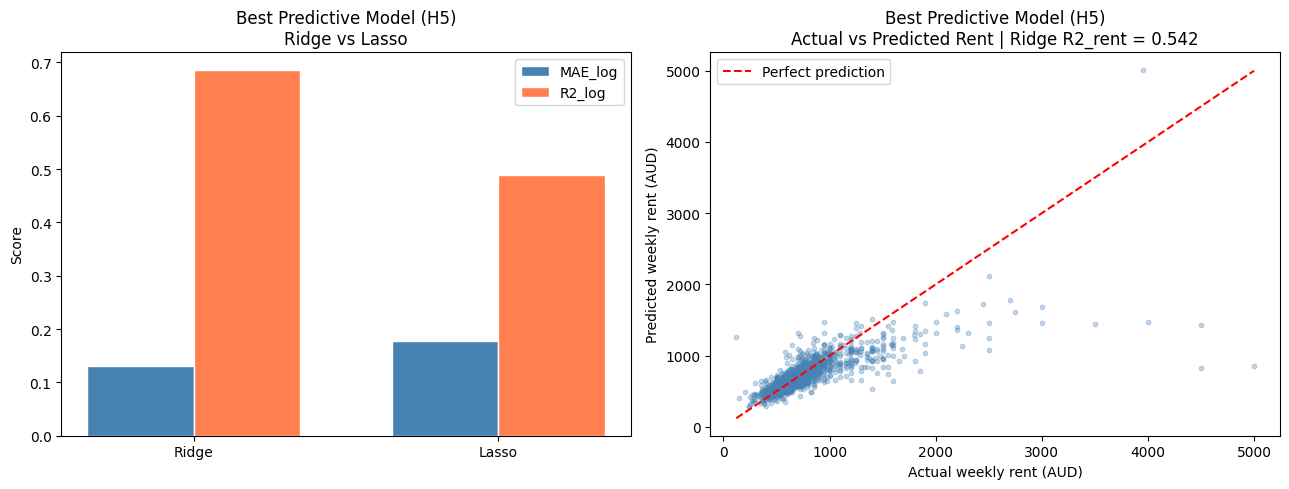

In [85]:
# Recreates plots from H1 for H5

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Ridge vs Lasso
plot_df = results_h5_df.set_index("model")

models = plot_df.index.tolist()
x = np.arange(len(models))
width = 0.35

axes[0].bar( x - width / 2, plot_df["MAE_log"], width, label="MAE_log", color="steelblue", edgecolor="white" )

axes[0].bar( x + width / 2, plot_df["R2_log"], width, label="R2_log", color="coral", edgecolor="white" )
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].set_title("Best Predictive Model (H5)\nRidge vs Lasso")
axes[0].set_ylabel("Score")
axes[0].legend()

# Ridge performance
ridge_h5_predictions = best_ridge_h5.predict(X_test_h5)

y_test_rent = np.expm1(y_test)
ridge_h5_predictions_rent = np.expm1(ridge_h5_predictions)

axes[1].scatter(y_test_rent, ridge_h5_predictions_rent, alpha=0.3, color="steelblue", s=10)
axes[1].plot([y_test_rent.min(), y_test_rent.max()], [y_test_rent.min(), y_test_rent.max()],"r--", linewidth=1.5, label="Perfect prediction")

axes[1].set_title( "Best Predictive Model (H5)\n"
    f"Actual vs Predicted Rent | Ridge R2_rent = {ridge_r2_rent_h5:.3f}")

axes[1].set_xlabel("Actual weekly rent (AUD)")
axes[1].set_ylabel("Predicted weekly rent (AUD)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [86]:
# H5: Extract amenity_count and compare H5 amenity effects to H4

amenity_df_h4 = amenity_df.copy()

# Put H5 feature names and coefficients into one table
coef_df_h5 = pd.DataFrame({"feature": X_train_h5.columns,"coef_log_h5": best_lasso_h5.coef_})

# Convert H5 coefficients to approximate percent effects
coef_df_h5["pct_effect_h5"] = (np.exp(coef_df_h5["coef_log_h5"]) - 1) * 100

# Amenity count effect
amenity_count_row = coef_df_h5[coef_df_h5["feature"] == "amenity_count"].copy()

print("Amenity count effect:")
display(amenity_count_row[["feature", "coef_log_h5", "pct_effect_h5"]].reset_index(drop=True))

# Individual H5 amenity effects
h2_features = set(X_geo.columns)
amenity_df_h5 = coef_df_h5[(~coef_df_h5["feature"].isin(h2_features)) &(coef_df_h5["feature"] != "amenity_count")].copy()
amenity_df_h5["amenity"] = amenity_df_h5["feature"]

# Bring in the H4 percent effects for comparison
h4_compare = amenity_df_h4[["amenity", "pct_effect"]].copy()
h4_compare = h4_compare.rename(columns={"pct_effect": "pct_effect_h4"})
amenity_compare = pd.merge(amenity_df_h5, h4_compare,on="amenity",how="left")

# Compute the change from H4 to H5
amenity_compare["delta"] = (amenity_compare["pct_effect_h5"] - amenity_compare["pct_effect_h4"])

# Split into positive, negative, and zero H5 coefficients
premium_amenities_h5 = amenity_compare[amenity_compare["coef_log_h5"] > 0].copy()
discount_amenities_h5 = amenity_compare[amenity_compare["coef_log_h5"] < 0].copy()
zeroed_amenities_h5 = amenity_compare[amenity_compare["coef_log_h5"] == 0].copy()
premium_amenities_h5 = premium_amenities_h5.sort_values(by="coef_log_h5", ascending=False)
discount_amenities_h5 = discount_amenities_h5.sort_values(by="coef_log_h5", ascending=True)

# Print summary
retained_count_h5 = len(amenity_compare[amenity_compare["coef_log_h5"] != 0])
zeroed_count_h5 = len(zeroed_amenities_h5)

print(f"\nAmenities retained by Lasso after adding amenity_count: {retained_count_h5}")
print(f"Amenities zeroed out by Lasso after adding amenity_count: {zeroed_count_h5}")

print("\nTop premium amenities:")
display(premium_amenities_h5[["amenity", "pct_effect_h4", "pct_effect_h5", "delta"]].head(10).reset_index(drop=True))

print("\nTop discount amenities:")
display(discount_amenities_h5[["amenity", "pct_effect_h4", "pct_effect_h5", "delta"]].head(10).reset_index(drop=True))

Amenity count effect:


,feature,coef_log_h5,pct_effect_h5
0,amenity_count,0.017219,1.73679



Amenities retained by Lasso after adding amenity_count: 30
Amenities zeroed out by Lasso after adding amenity_count: 52

Top premium amenities:


,amenity,pct_effect_h4,pct_effect_h5,delta
0,swimming pool - inground,11.912958,9.828218,-2.084739
1,open fireplace,6.168283,3.413960,-2.754323
2,balcony,4.883700,2.924010,-1.959690
3,deck,4.552953,2.640571,-1.912381
4,floorboards,4.103318,2.310878,-1.792439
5,outdoor entertaining area,3.797468,1.828254,-1.969214
6,open spaces: 2,2.488200,1.587028,-0.901171
7,study,3.924142,1.505205,-2.418937
8,courtyard,3.107552,1.315470,-1.792082
9,intercom,3.018931,0.945741,-2.073190



Top discount amenities:


,amenity,pct_effect_h4,pct_effect_h5,delta
0,fully fenced,-4.976119,-7.087011,-2.110891
1,split-system air conditioning,-1.894946,-4.388136,-2.493190
2,evaporative cooling,-1.920325,-4.385111,-2.464786
3,toilets: 2,-2.436357,-4.204246,-1.767889
4,toilets: 1,-1.905598,-3.886706,-1.981107
5,air conditioning,-1.774807,-3.496066,-1.721259
6,remote garage,-0.468768,-2.772119,-2.303351
7,secure parking,-0.609003,-2.642063,-2.033060
8,ensuite: 1,-0.375936,-2.345346,-1.969410
9,broadband internet available,0.000000,-2.038494,-2.038494


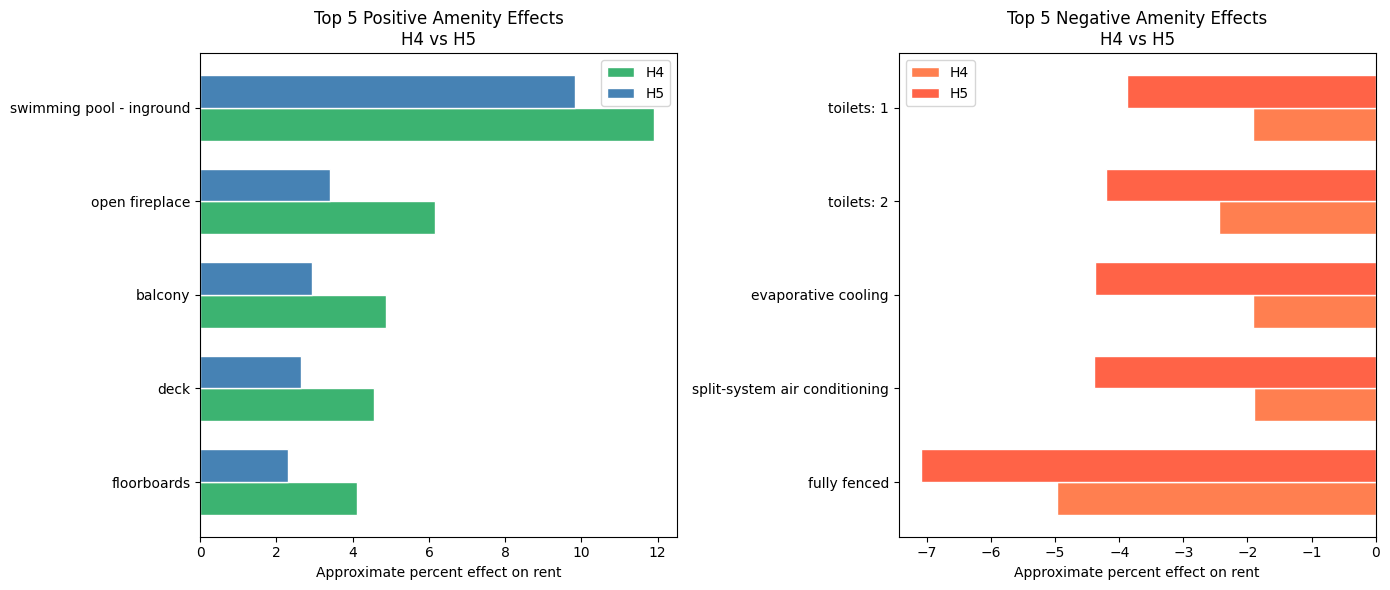

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 5 positive amenities: H4 vs H5
top_positive_compare = premium_amenities_h5.head(5).copy()
top_positive_compare = top_positive_compare.sort_values(by="pct_effect_h5", ascending=True)

y_pos = np.arange(len(top_positive_compare))
bar_height = 0.35

axes[0].barh(y_pos - bar_height / 2,top_positive_compare["pct_effect_h4"],height=bar_height,
    color="mediumseagreen",edgecolor="white",label="H4")

axes[0].barh(y_pos + bar_height / 2,top_positive_compare["pct_effect_h5"],
    height=bar_height,color="steelblue",edgecolor="white",label="H5")

axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(top_positive_compare["amenity"])
axes[0].set_title("Top 5 Positive Amenity Effects\nH4 vs H5")
axes[0].set_xlabel("Approximate percent effect on rent")
axes[0].set_ylabel("")
axes[0].legend()

# Top 5 negative amenities: H4 vs H5
top_negative_compare = discount_amenities_h5.head(5).copy()
top_negative_compare = top_negative_compare.sort_values(by="pct_effect_h5", ascending=True)

y_neg = np.arange(len(top_negative_compare))

axes[1].barh(y_neg - bar_height / 2,top_negative_compare["pct_effect_h4"],
    height=bar_height,color="coral",edgecolor="white",label="H4")

axes[1].barh(y_neg + bar_height / 2,top_negative_compare["pct_effect_h5"],
    height=bar_height,color="tomato",edgecolor="white",label="H5")

axes[1].set_yticks(y_neg)
axes[1].set_yticklabels(top_negative_compare["amenity"])
axes[1].set_title("Top 5 Negative Amenity Effects\nH4 vs H5")
axes[1].set_xlabel("Approximate percent effect on rent")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

### H5 Summary

Adding amenity_count to the model introduces a premium of about **+1.74% in predicted rent for each additional listed amenity**, capturing the idea that more feature-rich properties tend to rent for more overall.

Once that general count premium is included, it is expected that many of the positive individual amenity coefficients become smaller, because part of their earlier H4 signal was really reflecting overall amenity richness. In H5, the remaining coefficient for a specific amenity can be interpreted as whether that feature adds more or less value than a typical additional amenity.

This makes the negative coefficients especially informative. Features such as toilets: 1 are not really amenities, so once they receive the amenity-count premium, their individual coefficients adjust downward. The H5 results suggest that some features are less valuable than the average extra amenity, while others, such as pools and fireplaces, still retain distinct positive associations even after controlling for amenity count.

Overall, H5 shows that rental price depends on both **amenity quantity** and **amenity composition**: there is a modest premium for having more amenities overall, but certain amenities still carry their own distinct association with rent after adjusting for that general richness effect.

# 7. Conclusions and Summary of Findings

This analysis examined the **Australian Rental Market Data 2026 dataset** to understand the factors that influence weekly rental prices. We developed the predictive model iteratively, adding groups of variables in stages and evaluating how each set of features improved explanatory power.

---
### The Incremental Model Story

| Stage | R2_log | MAE_log | R2_rent | MAE_rent | Key Finding |
|---|---:|---:|---:|---:|---|
| H1: Fundamentals | 0.372 | 0.199 | 0.236 | 162.46 | Property fundamentals explain some rent variation, but the model remains limited. |
| H2: + Geography | 0.665 | 0.137 | 0.524 | 115.55 | Location is the dominant driver of rent and adds major explanatory power beyond fundamentals. |
| H3: + Amenities | 0.685 | 0.132 | 0.542 | 111.63 | Amenities add a modest but consistent improvement beyond fundamentals and geography. |
| H5: + Amenity Richness | 0.685 | 0.132 | 0.542 | 111.56 | Overall amenity richness explains part of the amenity signal, but the gain over H3 is very small. |

The largest improvement came when **geographic information** was introduced. Adding postcode and state increased explanatory power dramatically, confirming that **where a property is located plays the dominant role in determining rent**.

Amenities improved predictive performance only modestly, suggesting that many amenities primarily reflect the quality of properties already located in higher-priced areas.

---

### Final Model Performance

Our final predictive model is the **H5 Ridge model**, which includes:

- property fundamentals  
- geographic indicators  
- individual amenities  
- overall amenity richness  

This model achieves:

- **R2_log = 0.685**, explaining about **69% of variation in log weekly rent**
- **MAE_log = 0.132**, indicating an average prediction error of about **0.132 log points**
- **R2_rent = 0.542**, explaining about **54% of variation in weekly rent on the original AUD scale**
- **MAE_rent = 111.56 AUD/week**, meaning predictions are off by about **112 AUD/week on average**

Because the model is trained on log-transformed rent, it is optimized to fit relative differences in price rather than extreme dollar values at the top of the market. As a result, the highest-rent listings are still underpredicted on the original rent scale, which is visible in the actual-versus-predicted plots. This is a common pattern in skewed price data and reflects the tradeoff between stable overall fit and precision at the upper tail.

---

## Contribution of Amenities on Price

Amenities contribute to rental prices in **two distinct ways**.

### 1. General Amenity Richness

The H5 model introduces an **amenity_count** variable representing the total number of amenities listed for each property.

The coefficient indicates an approximate **+1.74% increase in predicted rent for each additional listed amenity**, holding the other included variables fixed, suggesting that feature-rich properties generally command slightly higher rents.

### 2. Individual Amenity Effects

After controlling for amenity richness, several amenities still retain measurable effects.

Examples include:

| Amenity | H4 Effect | H5 Effect |
|---|---|---|
| Inground swimming pool | +11.9% | +9.8% |
| Open fireplace | +6.2% | +3.4% |
| Balcony | +4.9% | +2.9% |

The reduction in magnitude shows that **some of the premium observed in H4 was captured by amenity_count**.

On the negative side, several amenities became **more negative** after controlling for richness, including:

- fully fenced  
- split-system air conditioning  
- evaporative cooling  

These results are expected once amenity_count is added to the model. Because each additional listed feature already receives a general positive premium through the amenity-count coefficient, many of the individual positive amenity premiums become smaller in H5. The remaining coefficient for a specific amenity therefore reflects whether that feature adds more or less value than a typical additional amenity.

This also helps explain why features such as toilets: 1 can receive negative coefficients. Those items are not really amenities, so after receiving the general amenity-count premium, their individual coefficients adjust downward. In that sense, the negative H5 coefficients can be interpreted as features that are less valuable than the average additional amenity, conditional on the rest of the model.

---

## Central Finding

The analysis suggests three main drivers of rent:

1. **Location dominates price formation**  
2. **Property size provides moderate explanatory power**  
3. **Amenities contribute modestly, primarily through overall listing richness**

Specific amenities do matter, but much of the apparent amenity premium reflects **feature-rich properties in desirable areas**, rather than large independent price effects from individual amenities.

---

## Limitations

Several limitations should be considered when interpreting these results.

- **High-cardinality postcode variables**  
  Postcode indicators were effective for prediction, but they are not especially interpretable. More structured geographic features, such as spatial clustering or distance-based measures, could provide a cleaner representation of location.

- **Cross-sectional dataset**  
  The analysis identifies conditional associations, not causal effects. A positive amenity coefficient does not mean that adding that amenity would necessarily increase rent by the estimated amount.

- **Listing-level amenity data**  
  Amenity information is self-reported and may vary in completeness or consistency across listings. Some features may be missing, inconsistently labeled, or represented differently across properties.

---

## Overall Takeaway

The final model shows that **location is the strongest driver of rental price**, while **property fundamentals and amenities provide additional explanatory value**. H5 adds a useful refinement by separating the general premium for feature-rich listings from the distinct associations of specific amenities, making the amenity results easier to interpret.